# CES 2022 Voter Analysis

## Exploring Demographic and Political Patterns in Voter Turnout

### Research Objective

This project analyzes data from the 2022 Cooperative Election Study (CES) to explore how demographic and political characteristics are associated with self-reported voter turnout in the 2022 U.S. midterm elections.

The analysis focuses on age, gender, education, and party identification.

## part1 - voter participation 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df =pd.read_csv("CCES22_Common_OUTPUT_vv_topost.csv",
    nrows=1000
               )

In [3]:
df.shape

(1000, 707)

In [4]:
df.head()

,Unnamed: 0,caseid,commonweight,commonpostweight,vvweight,vvweight_post,tookpost,CCEStake,add_confirm,inputzip,...,TS_g2022,TS_p2022,TS_p2022_party,TS_state,TS_partyreg,starttime,endtime,starttime_post,endtime_post,sourcevar
0,1,1983126005,3.649671,3.525008,4.487326,3.979634,2,1,1.0,NaN,...,1.0,1.0,NaN,23.0,NaN,2022-09-29 00:10:59,2022-09-29 00:26:13,2022-11-28 04:03:31,2022-11-28 04:14:36,2
1,2,1983126559,0.780431,0.818539,0.645634,0.640604,2,1,NaN,1331.0,...,6.0,6.0,6.0,20.0,NaN,2022-09-29 00:13:20,2022-09-29 00:26:35,2022-12-07 11:27:52,2022-12-07 11:40:09,2
2,3,1983126197,0.891555,0.774314,0.869904,0.830826,2,1,1.0,NaN,...,3.0,7.0,NaN,39.0,2.0,2022-09-29 00:12:44,2022-09-29 00:27:29,2022-11-20 23:20:50,2022-11-20 23:40:15,2
3,4,1979974411,1.103598,1.207156,1.063535,0.985901,2,1,NaN,6716.0,...,4.0,4.0,NaN,7.0,2.0,2022-09-29 00:10:33,2022-09-29 00:30:55,2022-11-19 13:42:13,2022-11-19 15:27:12,2
4,5,1983130427,0.542923,0.327550,0.559116,0.391543,2,1,2.0,21401.0,...,7.0,7.0,NaN,21.0,NaN,2022-09-29 00:14:06,2022-09-29 00:35:23,2022-12-02 17:21:47,2022-12-02 17:45:00,2


In [5]:
df.columns.tolist()

['Unnamed: 0',
 'caseid',
 'commonweight',
 'commonpostweight',
 'vvweight',
 'vvweight_post',
 'tookpost',
 'CCEStake',
 'add_confirm',
 'inputzip',
 'birthyr',
 'gender4',
 'gender4_t',
 'educ',
 'race',
 'race_other',
 'hispanic',
 'multrace_1',
 'multrace_2',
 'multrace_3',
 'multrace_4',
 'multrace_5',
 'multrace_8',
 'multrace_97',
 'multrace_98',
 'comptype',
 'votereg',
 'votereg_f',
 'regzip',
 'pid3',
 'pid3_t',
 'pid7',
 'inputstate',
 'region',
 'ccesmodule',
 'CC22_300_1',
 'CC22_300_2',
 'CC22_300_3',
 'CC22_300_4',
 'CC22_300_5',
 'CC22_300a',
 'CC22_300c',
 'CC22_300b_1',
 'CC22_300b_2',
 'CC22_300b_3',
 'CC22_300b_4',
 'CC22_300b_5',
 'CC22_300b_6',
 'CC22_300b_7',
 'CC22_300b_8',
 'CC22_300d_1',
 'CC22_300d_2',
 'CC22_300d_3',
 'CC22_300d_4',
 'CC22_300d_5',
 'CC22_300d_6',
 'CC22_302',
 'CC22_303',
 'CC22_304',
 'CC22_305_1',
 'CC22_305_2',
 'CC22_305_3',
 'CC22_305_4',
 'CC22_305_5',
 'CC22_305_6',
 'CC22_305_7',
 'CC22_305_9',
 'CC22_305_10',
 'CC22_305_11',
 'CC22

In [6]:
[col for col in df.columns if 'vote'in col.lower()]

['votereg',
 'votereg_f',
 'presvote20post',
 'presvote20post_t',
 'CC22_365_voted',
 'CC22_365_voted_t',
 'CC22_365b_voted',
 'CC22_365b_voted_t',
 'CC22_366_voted',
 'CC22_366_voted_t',
 'CC22_367_voted',
 'CC22_367_voted_t',
 'presvote16post',
 'presvote16post_t',
 'page_CC22_365_voted_timing',
 'page_CC22_365b_voted_timing',
 'page_CC22_366_voted_timing',
 'page_CC22_367_voted_timing',
 'page_presvote20post_timing',
 'page_presvote16post_timing',
 'votereg_post',
 'votereg_f_post',
 'TS_voterstatus']

In [7]:
[col for col in df.columns if 'party'in col.lower()]

['CurrentGovParty',
 'CurrentHouseParty',
 'CurrentSen1Party',
 'CurrentSen2Party',
 'GovCand1Party',
 'GovCand2Party',
 'GovCand3Party',
 'HouseCand1Party',
 'HouseCand2Party',
 'HouseCand3Party',
 'HouseCand4Party',
 'HouseCand5Party',
 'HouseCand6Party',
 'HouseCand7Party',
 'HouseCand8Party',
 'SenCand1Party',
 'SenCand2Party',
 'SenCand3Party',
 'SenCand4Party',
 'SenCand1Party2',
 'SenCand2Party2',
 'CurrentGovParty_post',
 'CurrentHouseParty_post',
 'CurrentSen1Party_post',
 'CurrentSen2Party_post',
 'GovCand1Party_post',
 'GovCand2Party_post',
 'GovCand3Party_post',
 'HouseCand1Party_post',
 'HouseCand2Party_post',
 'HouseCand3Party_post',
 'HouseCand4Party_post',
 'HouseCand5Party_post',
 'HouseCand6Party_post',
 'HouseCand7Party_post',
 'HouseCand8Party_post',
 'SenCand1Party_post',
 'SenCand2Party_post',
 'SenCand3Party_post',
 'SenCand4Party_post',
 'SenCand1Party2_post',
 'SenCand2Party2_post',
 'AttCand1Party',
 'AttCand2Party',
 'AttCand3Party',
 'SecCand1Party',
 'SecCa

In [8]:
[col for col in df.columns if 'income'in col.lower()]

[]

In [9]:
df['educ'].value_counts()

educ
5    253
2    223
3    217
6    149
4    130
1     28
Name: count, dtype: int64

In [10]:
[col for col in df.columns if 'vote'in col.lower()]

['votereg',
 'votereg_f',
 'presvote20post',
 'presvote20post_t',
 'CC22_365_voted',
 'CC22_365_voted_t',
 'CC22_365b_voted',
 'CC22_365b_voted_t',
 'CC22_366_voted',
 'CC22_366_voted_t',
 'CC22_367_voted',
 'CC22_367_voted_t',
 'presvote16post',
 'presvote16post_t',
 'page_CC22_365_voted_timing',
 'page_CC22_365b_voted_timing',
 'page_CC22_366_voted_timing',
 'page_CC22_367_voted_timing',
 'page_presvote20post_timing',
 'page_presvote16post_timing',
 'votereg_post',
 'votereg_f_post',
 'TS_voterstatus']

In [11]:
[col for col in df.columns if 'party'in col.lower()]

['CurrentGovParty',
 'CurrentHouseParty',
 'CurrentSen1Party',
 'CurrentSen2Party',
 'GovCand1Party',
 'GovCand2Party',
 'GovCand3Party',
 'HouseCand1Party',
 'HouseCand2Party',
 'HouseCand3Party',
 'HouseCand4Party',
 'HouseCand5Party',
 'HouseCand6Party',
 'HouseCand7Party',
 'HouseCand8Party',
 'SenCand1Party',
 'SenCand2Party',
 'SenCand3Party',
 'SenCand4Party',
 'SenCand1Party2',
 'SenCand2Party2',
 'CurrentGovParty_post',
 'CurrentHouseParty_post',
 'CurrentSen1Party_post',
 'CurrentSen2Party_post',
 'GovCand1Party_post',
 'GovCand2Party_post',
 'GovCand3Party_post',
 'HouseCand1Party_post',
 'HouseCand2Party_post',
 'HouseCand3Party_post',
 'HouseCand4Party_post',
 'HouseCand5Party_post',
 'HouseCand6Party_post',
 'HouseCand7Party_post',
 'HouseCand8Party_post',
 'SenCand1Party_post',
 'SenCand2Party_post',
 'SenCand3Party_post',
 'SenCand4Party_post',
 'SenCand1Party2_post',
 'SenCand2Party2_post',
 'AttCand1Party',
 'AttCand2Party',
 'AttCand3Party',
 'SecCand1Party',
 'SecCa

In [12]:
df.columns.tolist()

['Unnamed: 0',
 'caseid',
 'commonweight',
 'commonpostweight',
 'vvweight',
 'vvweight_post',
 'tookpost',
 'CCEStake',
 'add_confirm',
 'inputzip',
 'birthyr',
 'gender4',
 'gender4_t',
 'educ',
 'race',
 'race_other',
 'hispanic',
 'multrace_1',
 'multrace_2',
 'multrace_3',
 'multrace_4',
 'multrace_5',
 'multrace_8',
 'multrace_97',
 'multrace_98',
 'comptype',
 'votereg',
 'votereg_f',
 'regzip',
 'pid3',
 'pid3_t',
 'pid7',
 'inputstate',
 'region',
 'ccesmodule',
 'CC22_300_1',
 'CC22_300_2',
 'CC22_300_3',
 'CC22_300_4',
 'CC22_300_5',
 'CC22_300a',
 'CC22_300c',
 'CC22_300b_1',
 'CC22_300b_2',
 'CC22_300b_3',
 'CC22_300b_4',
 'CC22_300b_5',
 'CC22_300b_6',
 'CC22_300b_7',
 'CC22_300b_8',
 'CC22_300d_1',
 'CC22_300d_2',
 'CC22_300d_3',
 'CC22_300d_4',
 'CC22_300d_5',
 'CC22_300d_6',
 'CC22_302',
 'CC22_303',
 'CC22_304',
 'CC22_305_1',
 'CC22_305_2',
 'CC22_305_3',
 'CC22_305_4',
 'CC22_305_5',
 'CC22_305_6',
 'CC22_305_7',
 'CC22_305_9',
 'CC22_305_10',
 'CC22_305_11',
 'CC22

In [13]:
variables = [
    'gender4',
    'birthyr',
    'educ',
    'race',
    'pid3',
    'pid7',
    'region',
    'votereg',
    'CC22_401',
    'CC22_402a',
    'CC22_403',
    'CC22_404',
    'CC22_406a',
    'CC22_412',
    'commonpostweight',
    'vvweight_post'
]

for var in variables:
    print(var, ":", var in df.columns)

gender4 : True
birthyr : True
educ : True
race : True
pid3 : True
pid7 : True
region : True
votereg : True
CC22_401 : True
CC22_402a : True
CC22_403 : True
CC22_404 : True
CC22_406a : True
CC22_412 : True
commonpostweight : True
vvweight_post : True


In [14]:
analysis_vars = [
    'gender4',
    'birthyr',
    'educ',
    'race',
    'pid3',
    'pid7',
    'region',
    'votereg',
    'CC22_401',
    'CC22_402a',
    'CC22_403',
    'CC22_404',
    'CC22_406a',
    'CC22_412',
    'commonpostweight',
    'vvweight_post'
]

voter_df = df[analysis_vars].copy()

voter_df.head()

,gender4,birthyr,educ,race,pid3,pid7,region,votereg,CC22_401,CC22_402a,CC22_403,CC22_404,CC22_406a,CC22_412,commonpostweight,vvweight_post
0,1,1992,6,1,1,1,2,1,5.0,NaN,3.0,NaN,1.0,1.0,3.525008,3.979634
1,1,1957,3,1,3,5,1,1,5.0,NaN,1.0,2.0,2.0,2.0,0.818539,0.640604
2,2,1978,5,1,1,1,1,1,5.0,NaN,3.0,NaN,1.0,1.0,0.774314,0.830826
3,3,1991,6,1,4,4,1,1,5.0,NaN,3.0,NaN,1.0,1.0,1.207156,0.985901
4,1,1991,6,1,3,4,3,1,1.0,17.0,NaN,NaN,NaN,NaN,0.327550,0.391543


In [15]:
voter_df.shape

(1000, 16)

In [16]:
df.shape

(1000, 707)

In [17]:
voter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender4           1000 non-null   int64  
 1   birthyr           1000 non-null   int64  
 2   educ              1000 non-null   int64  
 3   race              1000 non-null   int64  
 4   pid3              1000 non-null   int64  
 5   pid7              1000 non-null   int64  
 6   region            1000 non-null   int64  
 7   votereg           1000 non-null   int64  
 8   CC22_401          884 non-null    float64
 9   CC22_402a         157 non-null    float64
 10  CC22_403          778 non-null    float64
 11  CC22_404          506 non-null    float64
 12  CC22_406a         779 non-null    float64
 13  CC22_412          768 non-null    float64
 14  commonpostweight  924 non-null    float64
 15  vvweight_post     767 non-null    float64
dtypes: float64(8), int64(8)
memory usage: 125.1

In [18]:
gender_map = {
    1: 'Man',
    2: 'Woman',
    3: 'Non-binary',
    4: 'Other'
}

party_map = {
    1: 'Democrat',
    2: 'Republican',
    3: 'Independent',
    4: 'Other',
    5: 'Not sure'
}

region_map = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South',
    4: 'West'
}

voter_df['gender'] = voter_df['gender4'].map(gender_map)
voter_df['party'] = voter_df['pid3'].map(party_map)
voter_df['region_name'] = voter_df['region'].map(region_map)

voter_df[['gender4', 'gender', 'pid3', 'party', 
          'region', 'region_name']].head(10)

,gender4,gender,pid3,party,region,region_name
0,1,Man,1,Democrat,2,Midwest
1,1,Man,3,Independent,1,Northeast
2,2,Woman,1,Democrat,1,Northeast
3,3,Non-binary,4,Other,1,Northeast
4,1,Man,3,Independent,3,South
5,1,Man,3,Independent,1,Northeast
6,2,Woman,1,Democrat,3,South
7,1,Man,1,Democrat,3,South
8,2,Woman,1,Democrat,1,Northeast
9,1,Man,1,Democrat,3,South


In [19]:
education_map = {
    1: 'No HS',
    2: 'High school',
    3: 'Some college',
    4: '2-year degree',
    5: '4-year degree',
    6: 'Post-grad'
}

race_map = {
    1: 'White',
    2: 'Black',
    3: 'Hispanic',
    4: 'Asian',
    5: 'Native American',
    6: 'Middle Eastern',
    7: 'Two or more races',
    8: 'Other'
}

voter_df['education'] = voter_df['educ'].map(education_map)
voter_df['race_name'] = voter_df['race'].map(race_map)

In [20]:
voter_df['voted'] = voter_df['CC22_401'].map({
    1: 'No',
    2: 'No',
    3: 'No',
    4: 'No',
    5: 'Yes'
})

In [21]:
voter_df['age'] = 2022 - voter_df['birthyr']

In [22]:
voter_df[
    ['birthyr', 'age',
     'education', 'race_name',
     'gender', 'party',
     'region_name', 'voted']
].head(10)


,birthyr,age,education,race_name,gender,party,region_name,voted
0,1992,30,Post-grad,White,Man,Democrat,Midwest,Yes
1,1957,65,Some college,White,Man,Independent,Northeast,Yes
2,1978,44,4-year degree,White,Woman,Democrat,Northeast,Yes
3,1991,31,Post-grad,White,Non-binary,Other,Northeast,Yes
4,1991,31,Post-grad,White,Man,Independent,South,No
5,1955,67,4-year degree,Two or more races,Man,Independent,Northeast,Yes
6,1968,54,High school,Black,Woman,Democrat,South,Yes
7,1947,75,Post-grad,White,Man,Democrat,South,Yes
8,1947,75,4-year degree,White,Woman,Democrat,Northeast,Yes
9,1950,72,Post-grad,White,Man,Democrat,South,Yes


## Overall Voter Turnout
1- valid respondents that voted vs did not vote(counts)
2-percentage of valid respondents that voted vs did not vote 

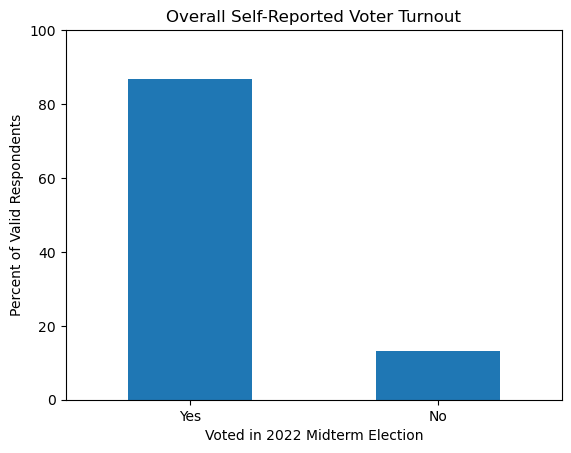

In [23]:
overall_turnout = voter_df['voted'].value_counts(normalize=True) * 100

overall_turnout.plot(kind='bar')

plt.title('Overall Self-Reported Voter Turnout')
plt.xlabel('Voted in 2022 Midterm Election')
plt.ylabel('Percent of Valid Respondents')
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [24]:
voter_df['voted'].value_counts()

voted
Yes    767
No     117
Name: count, dtype: int64

In [25]:
voter_df['voted'].value_counts(normalize=True) * 100

voted
Yes    86.764706
No     13.235294
Name: proportion, dtype: float64

## Voter Turnout by Gender

In [26]:
# actual number of respondents that voted 
pd.crosstab(
    voter_df['gender'],
    voter_df['voted']
)

voted,No,Yes
gender,,
Man,43,379
Non-binary,0,4
Other,1,1
Woman,73,383


In [27]:
gender_turnout = pd.crosstab(
    voter_df['gender'],
    voter_df['voted'],
    normalize='index'
) * 100

gender_turnout

voted,No,Yes
gender,,
Man,10.189573,89.810427
Non-binary,0.000000,100.000000
Other,50.000000,50.000000
Woman,16.008772,83.991228


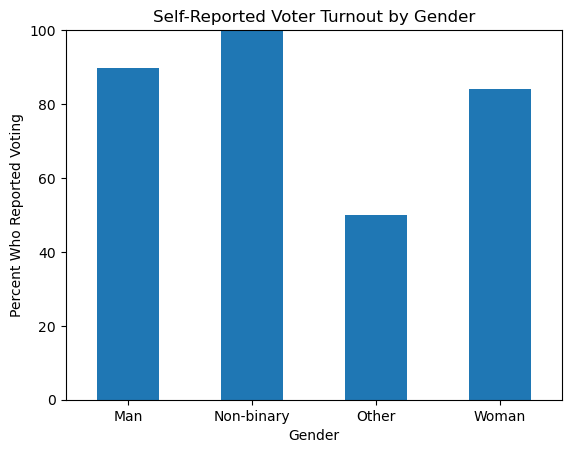

In [28]:
gender_turnout['Yes'].plot(kind='bar')

plt.title('Self-Reported Voter Turnout by Gender')
plt.xlabel('Gender')
plt.ylabel('Percent Who Reported Voting')
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

# **Finding:** Self-reported voter turnout differed moderately by gender in the working sample. Approximately 89.8% of men reported voting in the 2022 midterm election, compared with 84.0% of women, a difference of about 5.8 percentage points.

The non-binary and "Other" categories showed turnout rates of 100% and 50%, respectively. However, these groups contained only 4 and 2 respondents with valid turnout responses, so these percentages should not be interpreted as reliable patterns.

## Voter Turnout by Age Group

In [29]:
voter_df['age_group'] = pd.cut(
    voter_df['age'],
    bins=[17, 29, 44, 64, 120],
    labels=['18–29', '30–44', '45–64', '65+']
)

voter_df[['age', 'age_group']].head(10)

,age,age_group
0,30,30–44
1,65,65+
2,44,30–44
3,31,30–44
4,31,30–44
5,67,65+
6,54,45–64
7,75,65+
8,75,65+
9,72,65+


In [30]:
pd.crosstab(
    voter_df['age_group'],
    voter_df['voted']
)

voted,No,Yes
age_group,,
18–29,29,59
30–44,37,133
45–64,34,292
65+,17,283


In [31]:
age_turnout = pd.crosstab(
    voter_df['age_group'],
    voter_df['voted'],
    normalize='index'
) * 100

age_turnout

voted,No,Yes
age_group,,
18–29,32.954545,67.045455
30–44,21.764706,78.235294
45–64,10.429448,89.570552
65+,5.666667,94.333333


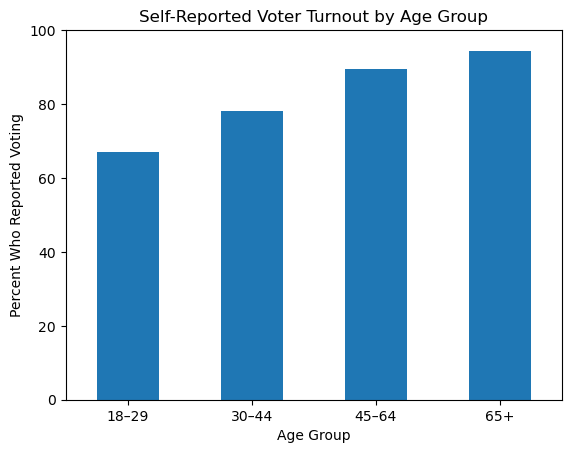

In [32]:
age_turnout['Yes'].plot(kind='bar')

plt.title('Self-Reported Voter Turnout by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percent Who Reported Voting')
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

**Finding:** Self-reported voter turnout increased consistently with age in the working sample. Approximately 67% of respondents aged 18–29 reported voting, compared with 78% among those aged 30–44, 90% among those aged 45–64, and 94% among respondents aged 65 and older.

This descriptive pattern suggests that age is strongly associated with electoral participation in the working sample.

## Voter Turnout by Education

In [33]:
pd.crosstab(
    voter_df['education'],
    voter_df['voted']
)

voted,No,Yes
education,,
2-year degree,19,99
4-year degree,13,216
High school,37,143
No HS,7,10
Post-grad,8,139
Some college,33,160


In [34]:
education_turnout = pd.crosstab(
    voter_df['education'],
    voter_df['voted'],
    normalize='index'
) * 100

education_turnout

voted,No,Yes
education,,
2-year degree,16.101695,83.898305
4-year degree,5.676856,94.323144
High school,20.555556,79.444444
No HS,41.176471,58.823529
Post-grad,5.442177,94.557823
Some college,17.098446,82.901554


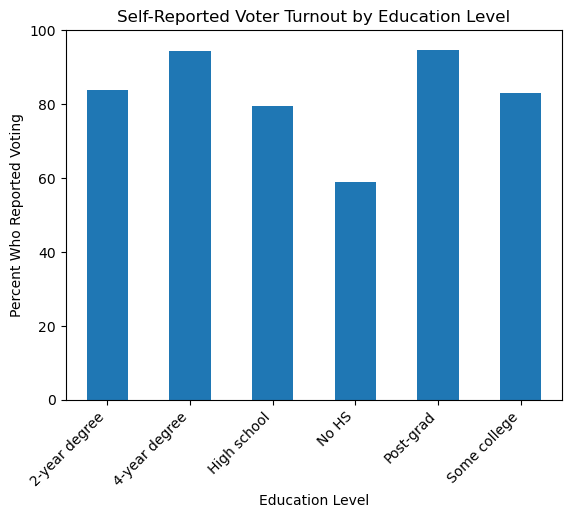

In [35]:
education_turnout['Yes'].plot(kind='bar')

plt.title('Self-Reported Voter Turnout by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Percent Who Reported Voting')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.show()

### Finding

reported turnout rises with education, especially once respondents reach a four-year degree or postgraduate level. The No HS category is only 17 people, though, so we should be cautious about treating its 58.8% as a precise estimate.

## Voter Turnout by Party Identification


In [36]:
#self-reported turnout by party identification
pd.crosstab(
    voter_df['party'],
    voter_df['voted']
)

voted,No,Yes
party,,
Democrat,32,296
Independent,40,214
Not sure,20,5
Other,5,45
Republican,20,207


In [37]:
party_turnout = pd.crosstab(
    voter_df['party'],
    voter_df['voted'],
    normalize='index'
) * 100

party_turnout

voted,No,Yes
party,,
Democrat,9.756098,90.243902
Independent,15.748031,84.251969
Not sure,80.000000,20.000000
Other,10.000000,90.000000
Republican,8.810573,91.189427


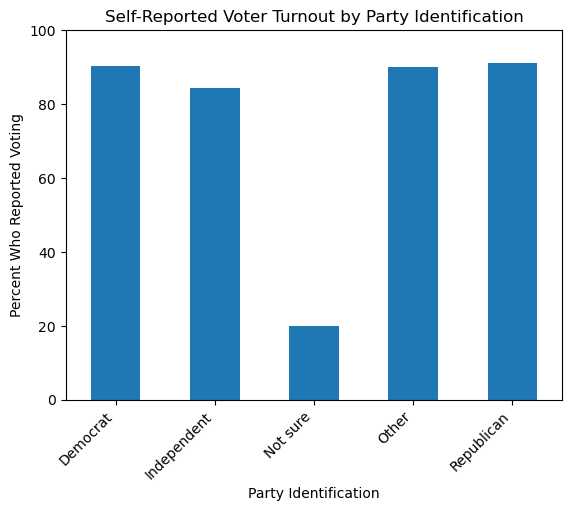

In [38]:
party_turnout['Yes'].plot(kind='bar')

plt.title('Self-Reported Voter Turnout by Party Identification')
plt.xlabel('Party Identification')
plt.ylabel('Percent Who Reported Voting')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.show()

### Finding

The main pattern is that Democrats and Republicans look very similar, while Independents reported somewhat lower turnout. The Not sure category is dramatically lower, but it is also quite small at only 25 respondents, so we should be cautious about over-interpreting it

## part 2 - vote choice 

### Vote Choice Analysis

This section examines voting patterns among respondents who reported their vote choice for the U.S. House in the 2022 midterm election.

In [39]:
voter_df['CC22_412'].value_counts(dropna=False).sort_index()

CC22_412
1.0     393
2.0     316
3.0       5
6.0       1
7.0       1
10.0     19
11.0     19
12.0      1
13.0     13
NaN     232
Name: count, dtype: int64

In [40]:
[col for col in df.columns if 'HouseCand' in col]

['HouseCand1Name',
 'HouseCand1Party',
 'HouseCand2Name',
 'HouseCand2Party',
 'HouseCand3Name',
 'HouseCand3Party',
 'HouseCand4Name',
 'HouseCand4Party',
 'HouseCand5Name',
 'HouseCand5Party',
 'HouseCand6Name',
 'HouseCand6Party',
 'HouseCand7Name',
 'HouseCand7Party',
 'HouseCand8Name',
 'HouseCand8Party',
 'HouseCand1Name_post',
 'HouseCand1Party_post',
 'HouseCand2Name_post',
 'HouseCand2Party_post',
 'HouseCand3Name_post',
 'HouseCand3Party_post',
 'HouseCand4Name_post',
 'HouseCand4Party_post',
 'HouseCand5Name_post',
 'HouseCand5Party_post',
 'HouseCand6Name_post',
 'HouseCand6Party_post',
 'HouseCand7Name_post',
 'HouseCand7Party_post',
 'HouseCand8Name_post',
 'HouseCand8Party_post']

In [41]:
df[
    [
        'CC22_412',
        'HouseCand1Party_post',
        'HouseCand2Party_post',
        'HouseCand3Party_post'
    ]
].head(20)

,CC22_412,HouseCand1Party_post,HouseCand2Party_post,HouseCand3Party_post
0,1.0,Democratic,Republican,Working Class
1,2.0,Democratic,Republican,NaN
2,1.0,Democratic,Republican,NaN
3,1.0,Democratic,Republican,NaN
4,NaN,Democratic,Republican,NaN
5,2.0,Democratic,Republican,NaN
6,1.0,Democratic,Republican,NaN
7,1.0,Democratic,Republican,Libertarian
8,1.0,Democratic,Republican,NaN
9,1.0,Democratic,Republican,NaN


In [42]:
df['HouseCand1Party_post'].value_counts(dropna=False)

HouseCand1Party_post
Democratic     865
-1              76
NaN             31
Libertarian     15
Independent     13
Name: count, dtype: int64

In [43]:
df['HouseCand2Party_post'].value_counts(dropna=False)

HouseCand2Party_post
Republican           901
-1                    76
Democratic             8
NaN                    5
Independent            5
Socialist Workers      3
Green                  2
Name: count, dtype: int64

In [44]:
house_party_cols = [
    'HouseCand1Party_post',
    'HouseCand2Party_post',
    'HouseCand3Party_post',
    'HouseCand4Party_post',
    'HouseCand5Party_post',
    'HouseCand6Party_post',
    'HouseCand7Party_post',
    'HouseCand8Party_post'
]

voter_df[house_party_cols] = df[house_party_cols]

In [45]:
def get_house_vote_party(row):
    vote = row['CC22_412']

    if pd.isna(vote):
        return None

    if 1 <= vote <= 8:
        column = f'HouseCand{int(vote)}Party_post'
        return row[column]

    return None

In [46]:
voter_df['house_vote_party'] = voter_df.apply(
    get_house_vote_party,
    axis=1
)

In [47]:
voter_df['house_vote_party'].value_counts(dropna=False)

house_vote_party
Democratic     388
Republican     316
None           284
Independent      6
Libertarian      6
Name: count, dtype: int64

In [48]:
party_summary = (
    voter_df['house_vote_party']
    .value_counts()
    .rename_axis('Party')
    .reset_index(name='Number_of_voters')
)

party_summary['Percentage'] = (
    party_summary['Number_of_voters']
    / party_summary['Number_of_voters'].sum()
    * 100
).round(2)

party_summary

,Party,Number_of_voters,Percentage
0,Democratic,388,54.19
1,Republican,316,44.13
2,Independent,6,0.84
3,Libertarian,6,0.84


### Investigating unidentified House-vote records

In [49]:
none_cases = voter_df[
    voter_df['house_vote_party'].isna()
]

none_cases['CC22_412'].value_counts(
    dropna=False
).sort_index()

CC22_412
10.0     19
11.0     19
12.0      1
13.0     13
NaN     232
Name: count, dtype: int64

In [50]:
special_house_responses = {
    10: 'Other candidate',
    11: 'Did not vote in House race',
    12: 'Did not vote',
    13: 'Not sure'
}

voter_df['house_vote_status'] = (
    voter_df['CC22_412']
    .map(special_house_responses)
)

voter_df.loc[
    voter_df['house_vote_party'].notna(),
    'house_vote_status'
] = 'Identified party choice'

voter_df['house_vote_status'] = (
    voter_df['house_vote_status']
    .fillna('Missing / not asked')
)

voter_df['house_vote_status'].value_counts()

house_vote_status
Identified party choice       716
Missing / not asked           232
Did not vote in House race     19
Other candidate                19
Not sure                       13
Did not vote                    1
Name: count, dtype: int64

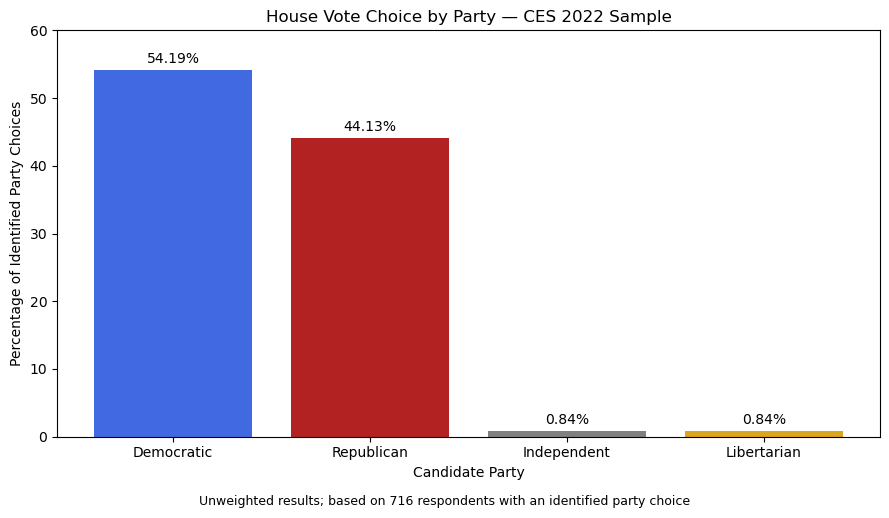

In [51]:
colors = ['royalblue', 'firebrick', 'gray', 'goldenrod']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    party_summary['Party'],
    party_summary['Percentage'],
    color=colors
)

plt.title('House Vote Choice by Party — CES 2022 Sample')
plt.xlabel('Candidate Party')
plt.ylabel('Percentage of Identified Party Choices')
plt.ylim(0, 60)

for bar, percentage in zip(bars, party_summary['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{percentage:.2f}%',
        ha='center'
    )

plt.figtext(
    0.5,
    -0.02,
    'Unweighted results; based on 716 respondents with an identified party choice',
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.show()

### Interpretation

Among the 716 respondents whose House candidate choice could be connected to a political party, 54.19% selected a Democratic candidate and 44.13% selected a Republican candidate. This represents a 10.06-percentage-point Democratic lead within the analysed sample. Independent and Libertarian candidates each received 0.84% of the identified choices.

A party choice could be identified for 71.6% of the original 1,000 respondents. The remaining respondents had missing answers or selected responses such as “Other candidate,” “Not sure,” or “Did not vote.” These results are unweighted and describe this sample only; they should not yet be treated as estimates for the entire United States electorate.

## House party choice by gender.

In [52]:
gender_columns = [
    column for column in voter_df.columns
    if 'gender' in column.lower()
]

gender_columns

['gender4', 'gender']

In [53]:
gender_mapping_check = (
    voter_df[['gender4', 'gender']]
    .drop_duplicates()
    .sort_values('gender4')
)

gender_mapping_check

,gender4,gender
0,1,Man
2,2,Woman
3,3,Non-binary
870,4,Other


#### Gender-by-party count table

In [54]:
party_order = [
    'Democratic',
    'Republican',
    'Independent',
    'Libertarian'
]

gender_party_counts = pd.crosstab(
    voter_df['gender'],
    voter_df['house_vote_party']
).reindex(
    columns=party_order,
    fill_value=0
)

gender_party_counts['Total'] = gender_party_counts.sum(axis=1)

gender_party_counts

ERROR! Session/line number was not unique in

house_vote_party,Democratic,Republican,Independent,Libertarian,Total
gender,,,,,
Man,181,171,3,1,356
Non-binary,4,0,0,0,4
Other,0,1,0,0,1
Woman,203,144,3,5,355


 database. History logging moved to new session 13


#### Percentage choosing each party within each gender group

In [55]:
gender_party_percent = (
    gender_party_counts[party_order]
    .div(gender_party_counts['Total'], axis=0)
    .mul(100)
    .round(2)
)

gender_party_percent['Valid_responses'] = (
    gender_party_counts['Total']
)

gender_party_percent

house_vote_party,Democratic,Republican,Independent,Libertarian,Valid_responses
gender,,,,,
Man,50.84,48.03,0.84,0.28,356
Non-binary,100.00,0.00,0.00,0.00,4
Other,0.00,100.00,0.00,0.00,1
Woman,57.18,40.56,0.85,1.41,355


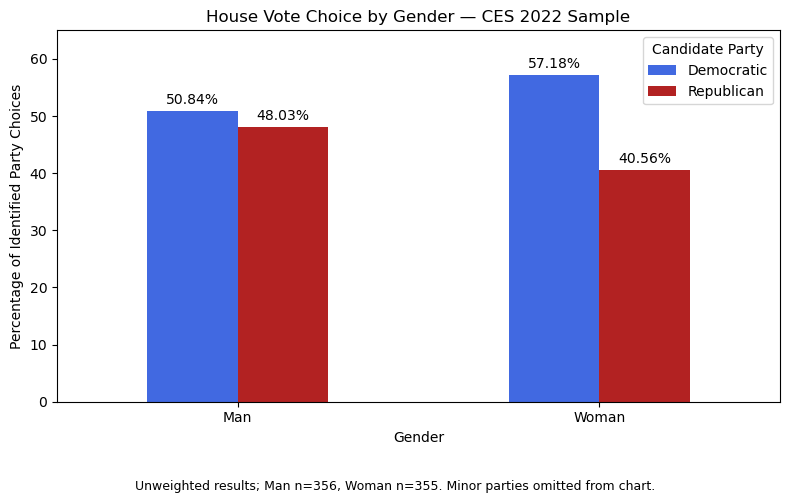

In [56]:
gender_chart_data = gender_party_percent.loc[
    ['Man', 'Woman'],
    ['Democratic', 'Republican']
]

fig, ax = plt.subplots(figsize=(8, 5))

gender_chart_data.plot(
    kind='bar',
    color=['royalblue', 'firebrick'],
    ax=ax
)

ax.set_title('House Vote Choice by Gender — CES 2022 Sample')
ax.set_xlabel('Gender')
ax.set_ylabel('Percentage of Identified Party Choices')
ax.set_ylim(0, 65)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Candidate Party')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

fig.text(
    0.5,
    0.01,
    'Unweighted results; Man n=356, Woman n=355. Minor parties omitted from chart.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

### Gender and House Vote Choice

Among respondents with an identified House party choice, women showed a stronger Democratic preference than men. Democratic candidates received 57.18% of women’s identified choices, compared with 50.84% among men—a difference of 6.34 percentage points.

Republican candidates received 48.03% of men’s identified choices and 40.56% of women’s choices. This represents a 7.47-percentage-point higher Republican share among men.

The Non-binary and Other categories were retained in the count table but excluded from the chart because they contained only four and one valid responses respectively. These unweighted results describe associations within this sample and do not establish that gender caused differences in vote choice.

## House party choice by age group.

In [57]:
age_columns = [
    column for column in voter_df.columns
    if 'age' in column.lower()
    or 'birth' in column.lower()
]

age_columns

['birthyr', 'age', 'age_group']

In [58]:
age_order = [
    '18–29',
    '30–44',
    '45–64',
    '65+'
]

voter_df['age_group'].value_counts(
    sort=False,
    dropna=False
)

age_group
18–29    124
30–44    198
45–64    360
65+      318
Name: count, dtype: int64

#### Age-group-by-party count table

In [59]:
age_party_counts = pd.crosstab(
    voter_df['age_group'],
    voter_df['house_vote_party']
).reindex(
    index=age_order,
    columns=party_order,
    fill_value=0
)

age_party_counts['Total'] = age_party_counts.sum(axis=1)

age_party_counts

house_vote_party,Democratic,Republican,Independent,Libertarian,Total
age_group,,,,,
18–29,40,14,1,0,55
30–44,81,39,2,3,125
45–64,141,128,2,2,273
65+,126,135,1,1,263


#### Percentage within each age group

In [60]:
age_party_percent = (
    age_party_counts[party_order]
    .div(age_party_counts['Total'], axis=0)
    .mul(100)
    .round(2)
)

age_party_percent['Valid_responses'] = (
    age_party_counts['Total']
)

age_party_percent

house_vote_party,Democratic,Republican,Independent,Libertarian,Valid_responses
age_group,,,,,
18–29,72.73,25.45,1.82,0.00,55
30–44,64.80,31.20,1.60,2.40,125
45–64,51.65,46.89,0.73,0.73,273
65+,47.91,51.33,0.38,0.38,263


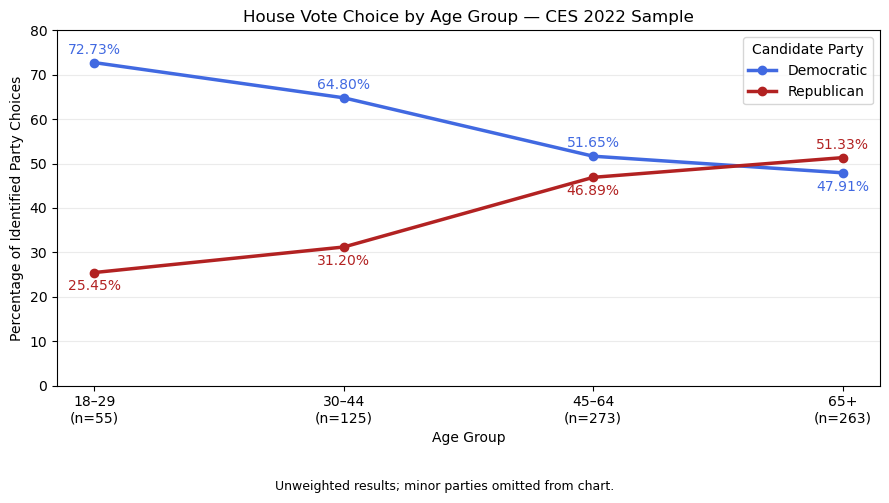

In [61]:
age_chart_data = age_party_percent.loc[
    age_order,
    ['Democratic', 'Republican']
]

x_positions = list(range(len(age_order)))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    x_positions,
    age_chart_data['Democratic'],
    marker='o',
    linewidth=2.5,
    color='royalblue',
    label='Democratic'
)

ax.plot(
    x_positions,
    age_chart_data['Republican'],
    marker='o',
    linewidth=2.5,
    color='firebrick',
    label='Republican'
)

for x, value in enumerate(age_chart_data['Democratic']):
    label_offset = -4 if age_order[x] == '65+' else 2

    ax.text(
        x,
        value + label_offset,
        f'{value:.2f}%',
        ha='center',
        color='royalblue'
    )

for x, value in enumerate(age_chart_data['Republican']):
    label_offset = 2 if age_order[x] == '65+' else -4

    ax.text(
        x,
        value + label_offset,
        f'{value:.2f}%',
        ha='center',
        color='firebrick'
    )

age_labels = [
    f'{group}\n(n={age_party_counts.loc[group, "Total"]})'
    for group in age_order
]

ax.set_xticks(x_positions)
ax.set_xticklabels(age_labels)
ax.set_ylim(0, 80)

ax.set_title('House Vote Choice by Age Group — CES 2022 Sample')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage of Identified Party Choices')
ax.legend(title='Candidate Party')
ax.grid(axis='y', alpha=0.25)

fig.text(
    0.5,
    0.01,
    'Unweighted results; minor parties omitted from chart.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

### Age and House Vote Choice

House party choice varied substantially across age groups in this sample. Democratic candidates received 72.73% of identified choices among respondents aged 18–29 and 64.80% among those aged 30–44. The Democratic share declined to 51.65% among respondents aged 45–64 and 47.91% among those aged 65 and above.

The Republican share followed the opposite pattern, increasing from 25.45% among respondents aged 18–29 to 51.33% among respondents aged 65 and above. Republicans held a narrow 3.42-percentage-point advantage in the oldest group, whereas Democrats led in the three younger groups.

The youngest group had only 55 valid party choices, making its estimate less stable than those for the older groups. These unweighted results describe an association between age and House vote choice within this sample; they do not prove that age caused the observed differences.

## House party choice by education level.

In [62]:
education_columns = [
    column for column in voter_df.columns
    if 'educ' in column.lower()
]

education_columns

['educ', 'education']

In [63]:
education_mapping_check = (
    voter_df[['educ', 'education']]
    .drop_duplicates()
    .sort_values('educ')
)

education_mapping_check

,educ,education
34,1,No HS
6,2,High school
1,3,Some college
13,4,2-year degree
2,5,4-year degree
0,6,Post-grad


#### Education-by-party count table

In [64]:
education_order = [
    'No HS',
    'High school',
    'Some college',
    '2-year degree',
    '4-year degree',
    'Post-grad'
]

education_party_counts = pd.crosstab(
    voter_df['education'],
    voter_df['house_vote_party']
).reindex(
    index=education_order,
    columns=party_order,
    fill_value=0
)

education_party_counts['Total'] = (
    education_party_counts.sum(axis=1)
)

education_party_counts

house_vote_party,Democratic,Republican,Independent,Libertarian,Total
education,,,,,
No HS,4,5,0,0,9
High school,61,72,0,1,134
Some college,74,76,1,1,152
2-year degree,44,43,0,3,90
4-year degree,121,80,2,1,204
Post-grad,84,40,3,0,127


#### Percentage selecting each party within each education level

In [65]:
education_party_percent = (
    education_party_counts[party_order]
    .div(education_party_counts['Total'], axis=0)
    .mul(100)
    .round(2)
)

education_party_percent['Valid_responses'] = (
    education_party_counts['Total']
)

education_party_percent

house_vote_party,Democratic,Republican,Independent,Libertarian,Valid_responses
education,,,,,
No HS,44.44,55.56,0.00,0.00,9
High school,45.52,53.73,0.00,0.75,134
Some college,48.68,50.00,0.66,0.66,152
2-year degree,48.89,47.78,0.00,3.33,90
4-year degree,59.31,39.22,0.98,0.49,204
Post-grad,66.14,31.50,2.36,0.00,127


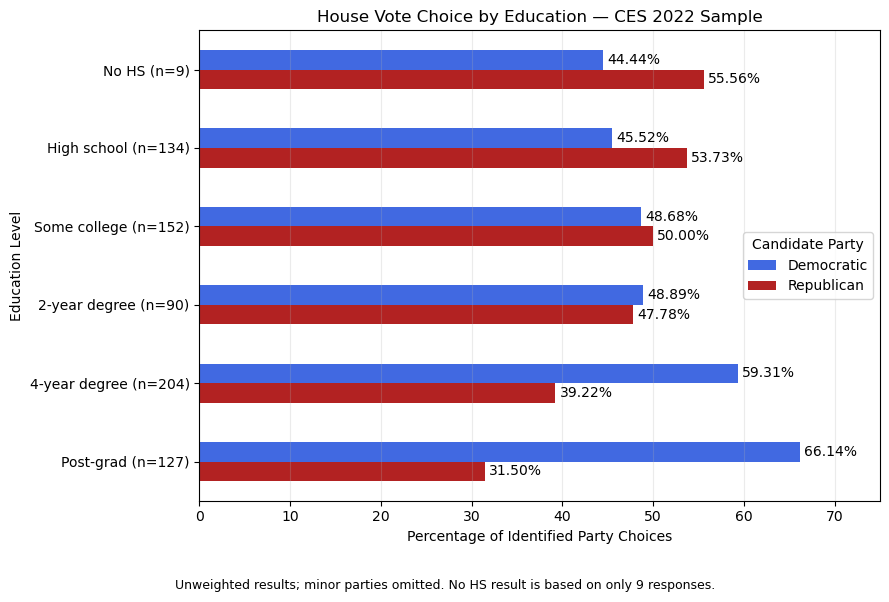

In [66]:
education_chart_data = education_party_percent.loc[
    education_order,
    ['Democratic', 'Republican']
].copy()

education_chart_data.index = [
    f'{level} (n={education_party_counts.loc[level, "Total"]})'
    for level in education_order
]

fig, ax = plt.subplots(figsize=(9, 6))

education_chart_data.plot(
    kind='barh',
    color=['royalblue', 'firebrick'],
    ax=ax
)

ax.set_title('House Vote Choice by Education — CES 2022 Sample')
ax.set_xlabel('Percentage of Identified Party Choices')
ax.set_ylabel('Education Level')
ax.set_xlim(0, 75)
ax.invert_yaxis()
ax.legend(title='Candidate Party')
ax.grid(axis='x', alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

fig.text(
    0.5,
    0.01,
    'Unweighted results; minor parties omitted. No HS result is based on only 9 responses.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Education and House Vote Choice

House party choice differed across education levels in this sample. Republican candidates received a larger share among respondents with a high-school education (53.73%) and a very small advantage among those with some college education (50.00% versus 48.68% Democratic). Respondents with a two-year degree were almost evenly divided.

A clearer Democratic advantage appeared among respondents with higher academic qualifications. Democratic candidates received 59.31% of identified choices among four-year degree holders and 66.14% among postgraduates. The corresponding Democratic leads were 20.09 and 34.64 percentage points.

The No HS category contained only nine valid responses, so its percentages are too unstable to support a strong conclusion. Overall, the results suggest an association between higher education and Democratic House vote choice within this unweighted sample. They do not establish that education caused the voting differences.

## House vote choice by respondents’ own party identification

In [67]:
party_id_columns = [
    column for column in voter_df.columns
    if 'pid' in column.lower()
    or 'party_id' in column.lower()
]

party_id_columns

['pid3', 'pid7']

In [68]:
party_id_map = {
    1: 'Democrat',
    2: 'Republican',
    3: 'Independent',
    4: 'Other',
    5: 'Not sure'
}

voter_df['party_id'] = (
    voter_df['pid3']
    .map(party_id_map)
)

party_id_mapping_check = (
    voter_df[['pid3', 'party_id']]
    .drop_duplicates()
    .sort_values('pid3')
)

party_id_mapping_check

,pid3,party_id
0,1,Democrat
15,2,Republican
1,3,Independent
3,4,Other
27,5,Not sure


In [69]:
party_id_order = [
    'Democrat',
    'Republican',
    'Independent',
    'Other',
    'Not sure'
]

party_id_vote_counts = pd.crosstab(
    voter_df['party_id'],
    voter_df['house_vote_party']
).reindex(
    index=party_id_order,
    columns=party_order,
    fill_value=0
)

party_id_vote_counts['Total'] = (
    party_id_vote_counts.sum(axis=1)
)

party_id_vote_counts

house_vote_party,Democratic,Republican,Independent,Libertarian,Total
party_id,,,,,
Democrat,262,7,1,2,272
Republican,7,195,0,0,202
Independent,97,93,5,2,197
Other,20,20,0,2,42
Not sure,2,1,0,0,3


#### Percentage choosing each candidate party within every party-identification group

In [70]:
party_id_vote_percent = (
    party_id_vote_counts[party_order]
    .div(party_id_vote_counts['Total'], axis=0)
    .mul(100)
    .round(2)
)

party_id_vote_percent['Valid_responses'] = (
    party_id_vote_counts['Total']
)

party_id_vote_percent

house_vote_party,Democratic,Republican,Independent,Libertarian,Valid_responses
party_id,,,,,
Democrat,96.32,2.57,0.37,0.74,272
Republican,3.47,96.53,0.00,0.00,202
Independent,49.24,47.21,2.54,1.02,197
Other,47.62,47.62,0.00,4.76,42
Not sure,66.67,33.33,0.00,0.00,3


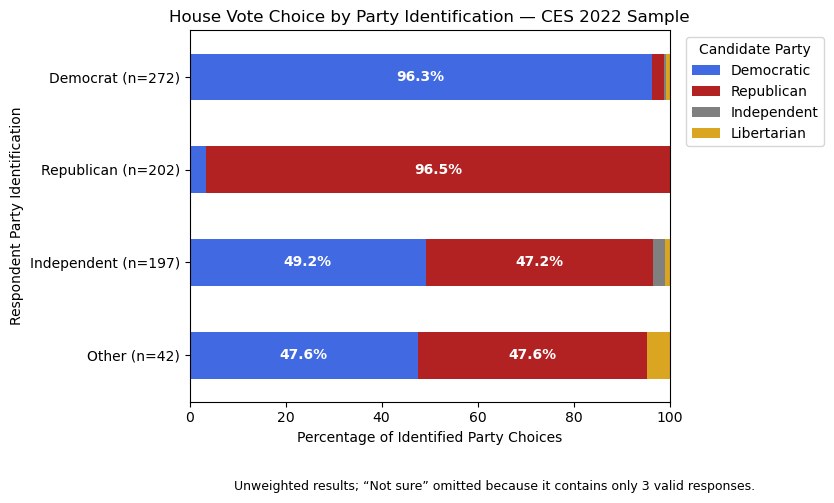

In [71]:
party_id_chart_order = [
    'Democrat',
    'Republican',
    'Independent',
    'Other'
]

party_id_chart_data = party_id_vote_percent.loc[
    party_id_chart_order,
    party_order
].copy()

party_id_chart_data.index = [
    f'{group} (n={party_id_vote_counts.loc[group, "Total"]})'
    for group in party_id_chart_order
]

fig, ax = plt.subplots(figsize=(10, 5))

party_id_chart_data.plot(
    kind='barh',
    stacked=True,
    color=['royalblue', 'firebrick', 'gray', 'goldenrod'],
    ax=ax
)

ax.set_title(
    'House Vote Choice by Party Identification — CES 2022 Sample'
)
ax.set_xlabel('Percentage of Identified Party Choices')
ax.set_ylabel('Respondent Party Identification')
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.legend(
    title='Candidate Party',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

for container in ax.containers:
    labels = [
        f'{value:.1f}%' if value >= 5 else ''
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        color='white',
        fontweight='bold'
    )

fig.text(
    0.5,
    0.01,
    'Unweighted results; “Not sure” omitted because it contains only 3 valid responses.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 0.85, 1])
plt.show()

### Party Identification and House Vote Choice

Respondents’ party identification was strongly associated with their House vote choice. Among self-identified Democrats, 96.32% selected a Democratic candidate. Similarly, 96.53% of self-identified Republicans selected a Republican candidate. Cross-party voting between these two groups was uncommon.

Independent respondents were almost evenly divided: 49.24% selected Democratic candidates and 47.21% selected Republican candidates, giving Democrats a narrow 2.03-percentage-point advantage. Respondents identifying with another party were evenly divided between Democratic and Republican candidates at 47.62% each.

The “Not sure” category was retained in the percentage table but excluded from the chart because it contained only three valid responses. These unweighted results show a strong association between party identification and candidate choice, but they do not prove causation.

## Survey weighting

In [72]:
weight_columns = [
    column for column in voter_df.columns
    if 'weight' in column.lower()
]

weight_columns

['commonpostweight', 'vvweight_post']

In [73]:
identified_voters = voter_df[
    voter_df['house_vote_party'].notna()
].copy()

weight_check = (
    identified_voters[
        ['commonpostweight', 'vvweight_post']
    ]
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .T
    .round(3)
)

weight_check['Missing'] = (
    len(identified_voters) - weight_check['count']
)

weight_check

,count,mean,median,min,max,Missing
commonpostweight,716.0,0.882,0.722,0.007,15.504,0.0
vvweight_post,644.0,0.946,0.799,0.059,10.729,72.0


In [74]:
identified_voters.shape

(716, 35)

In [75]:
unweighted_percent = (
    identified_voters['house_vote_party']
    .value_counts(normalize=True)
    .reindex(party_order, fill_value=0)
    .mul(100)
)

weighted_party_totals = (
    identified_voters
    .groupby(
        'house_vote_party',
        observed=True
    )['commonpostweight']
    .sum()
    .reindex(party_order, fill_value=0)
)

weighted_percent = (
    weighted_party_totals
    / weighted_party_totals.sum()
    * 100
)

weighted_comparison = pd.DataFrame({
    'Unweighted_percentage': unweighted_percent,
    'Weighted_percentage': weighted_percent
})

weighted_comparison['Difference_points'] = (
    weighted_comparison['Weighted_percentage']
    - weighted_comparison['Unweighted_percentage']
)

weighted_comparison = weighted_comparison.round(2)

weighted_comparison

,Unweighted_percentage,Weighted_percentage,Difference_points
house_vote_party,,,
Democratic,54.19,49.94,-4.25
Republican,44.13,49.42,5.28
Independent,0.84,0.41,-0.43
Libertarian,0.84,0.24,-0.60


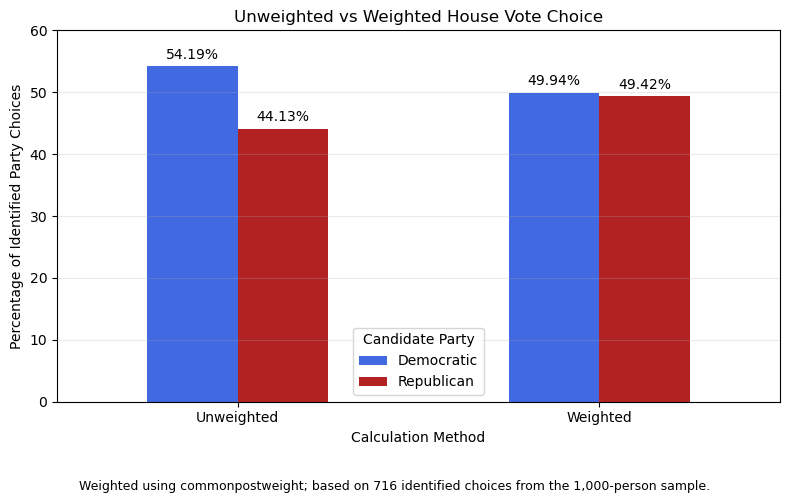

In [76]:
weight_chart_data = (
    weighted_comparison
    .loc[
        ['Democratic', 'Republican'],
        ['Unweighted_percentage', 'Weighted_percentage']
    ]
    .T
)

weight_chart_data.index = [
    'Unweighted',
    'Weighted'
]

fig, ax = plt.subplots(figsize=(8, 5))

weight_chart_data.plot(
    kind='bar',
    color=['royalblue', 'firebrick'],
    ax=ax
)

ax.set_title('Unweighted vs Weighted House Vote Choice')
ax.set_xlabel('Calculation Method')
ax.set_ylabel('Percentage of Identified Party Choices')
ax.set_ylim(0, 60)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Candidate Party')
ax.grid(axis='y', alpha=0.25)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

fig.text(
    0.5,
    0.01,
    'Weighted using commonpostweight; based on 716 identified choices from the 1,000-person sample.',
    ha='center',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

### Effect of Survey Weighting on House Vote Choice

The unweighted sample showed a 10.06-percentage-point Democratic advantage: 54.19% Democratic compared with 44.13% Republican.

After applying the CES `commonpostweight`, the result became nearly even. The estimated Democratic share decreased to 49.94%, while the Republican share increased to 49.42%, leaving a difference of only 0.52 percentage points.

Weighting therefore reduced the Democratic estimate by 4.25 points and increased the Republican estimate by 5.28 points. This indicates that the raw 1,000-person sample did not perfectly reflect the population characteristics used to construct the CES weights.

These figures are weighted estimates based on the 716 identifiable choices within the smaller working sample. They should be treated as exploratory results rather than official national CES estimates, which would require analysing the complete dataset.

## Reasons for Not Voting
What were the main reasons respondents did not vote?

In [77]:
# Keep only respondents classified as non-voters
nonvoters = voter_df[voter_df['voted'] == 'No'].copy()

print("Number of non-voters:", len(nonvoters))

# Examine the raw reason codes, including missing responses
nonvoters['CC22_402a'].value_counts(
    dropna=False
).sort_index()

Number of non-voters: 117


CC22_402a
1.0      4
2.0     12
3.0     13
4.0     18
5.0      2
6.0      4
7.0      9
8.0      9
9.0      2
10.0     2
11.0     3
12.0     1
13.0     4
14.0     1
15.0    15
16.0     1
17.0    13
55.0     4
Name: count, dtype: int64

In [78]:
# Translate the CES response codes into understandable labels
reason_map = {
    1: 'Forgot',
    2: 'Not interested',
    3: 'Too busy',
    4: 'Did not like the candidates',
    5: 'Not registered',
    6: 'Did not have correct identification',
    7: 'Out of town',
    8: 'Sick or disabled',
    9: 'Transportation problem',
    10: 'Bad weather',
    11: 'Line was too long',
    12: 'Not allowed to vote at the polls',
    13: 'Absentee ballot was not received',
    14: 'Did not know where to vote',
    15: 'Did not know enough about the choices',
    16: 'Afraid of COVID-19 exposure',
    17: 'Other',
    55: "Don't know"
}

# Create a new readable column
nonvoters['nonvoting_reason'] = (
    nonvoters['CC22_402a'].map(reason_map)
)

# Calculate counts and percentages
reason_table = (
    nonvoters['nonvoting_reason']
    .value_counts()
    .rename('Count')
    .to_frame()
)

reason_table['Percentage'] = (
    reason_table['Count'] / len(nonvoters) * 100
).round(2)

reason_table

,Count,Percentage
nonvoting_reason,,
Did not like the candidates,18,15.38
Did not know enough about the choices,15,12.82
Other,13,11.11
Too busy,13,11.11
Not interested,12,10.26
Out of town,9,7.69
Sick or disabled,9,7.69
Don't know,4,3.42
Did not have correct identification,4,3.42


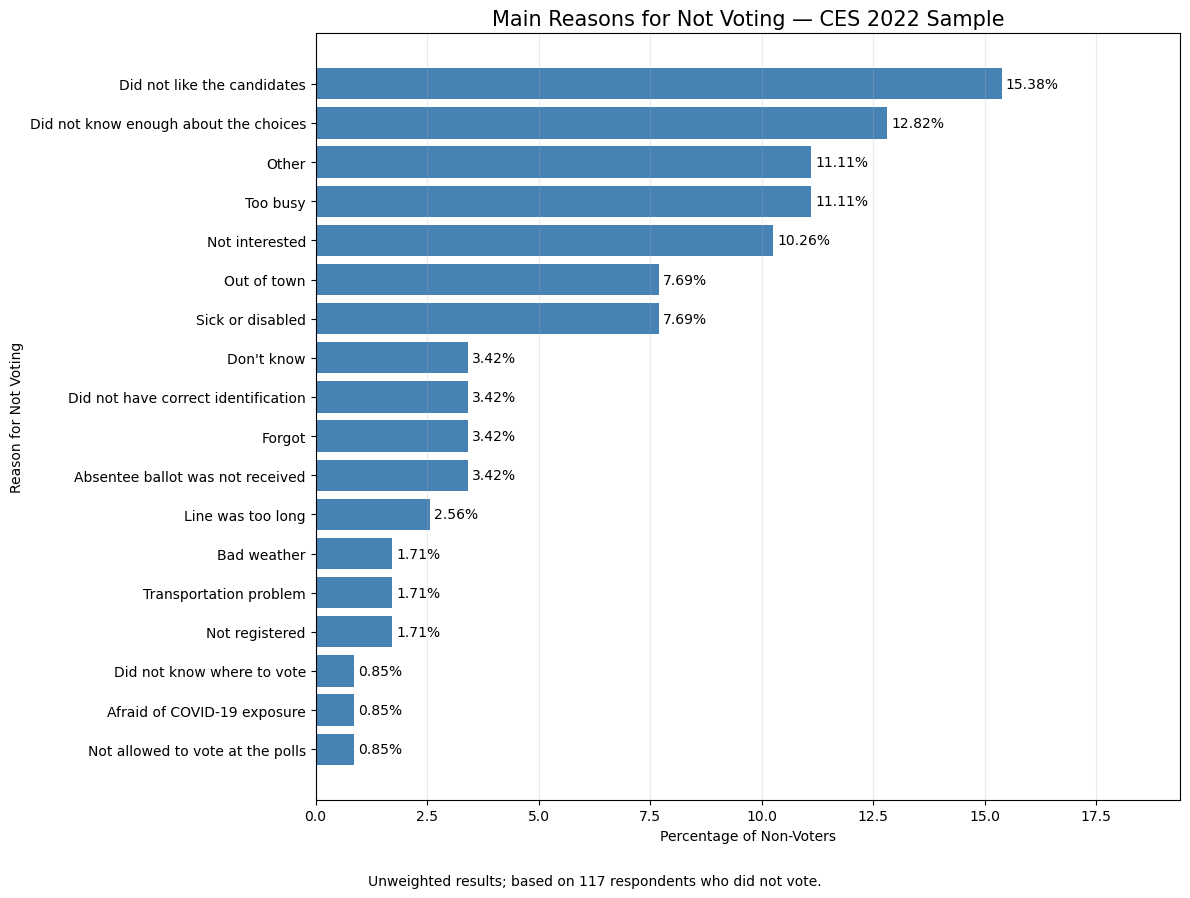

In [79]:
import matplotlib.pyplot as plt

# Arrange smaller percentages at the bottom and larger ones at the top
chart_data = reason_table.sort_values(
    'Percentage',
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    chart_data.index,
    chart_data['Percentage'],
    color='steelblue'
)

# Add percentage labels beside the bars
ax.bar_label(
    bars,
    fmt='%.2f%%',
    padding=3
)

ax.set_title(
    'Main Reasons for Not Voting — CES 2022 Sample',
    fontsize=15
)

ax.set_xlabel('Percentage of Non-Voters')
ax.set_ylabel('Reason for Not Voting')

# Leave room for the percentage labels
ax.set_xlim(
    0,
    chart_data['Percentage'].max() + 4
)

ax.grid(axis='x', alpha=0.25)

fig.text(
    0.5,
    0.01,
    'Unweighted results; based on 117 respondents who did not vote.',
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Finding

Among the 117 respondents who reported not voting, the most frequently reported reason was disliking the candidates (15.38%). This was followed by not knowing enough about the choices (12.82%). Being too busy and other unspecified reasons each accounted for 11.11%, while 10.26% reported that they were not interested.

No single explanation accounted for a majority—or even one-fifth—of non-voters. This suggests that non-voting in the working sample was associated with a mixture of candidate dissatisfaction, insufficient information, limited interest, personal circumstances, and practical barriers.

These are descriptive, unweighted results from the sample and should not be interpreted as proving why people did not vote across the entire US population.

## Voting Method

### Research Question

How did respondents who voted cast their ballots?

In [80]:
# Keep only respondents classified as voters
voters = voter_df[voter_df['voted'] == 'Yes'].copy()

print("Number of voters:", len(voters))

# Examine the raw voting-method codes
voters['CC22_403'].value_counts(
    dropna=False
).sort_index()

Number of voters: 767


CC22_403
1.0    314
2.0    185
3.0    267
NaN      1
Name: count, dtype: int64

In [81]:
# Translate the CES voting-method codes
voting_method_map = {
    1: 'In person on Election Day',
    2: 'In person before Election Day',
    3: 'By mail or absentee ballot'
}

# Create a readable voting-method column
voters['voting_method'] = (
    voters['CC22_403'].map(voting_method_map)
)

# Keep valid voting-method answers for this calculation
valid_voting_methods = voters[
    voters['voting_method'].notna()
].copy()

# Set the logical display order
method_order = [
    'In person on Election Day',
    'In person before Election Day',
    'By mail or absentee ballot'
]

# Calculate counts
method_counts = (
    valid_voting_methods['voting_method']
    .value_counts()
    .reindex(method_order, fill_value=0)
)

# Create the results table
method_table = pd.DataFrame({
    'Count': method_counts,
    'Percentage': (
        method_counts / method_counts.sum() * 100
    ).round(2)
})

method_table.index.name = 'Voting_method'

method_table

,Count,Percentage
Voting_method,,
In person on Election Day,314,40.99
In person before Election Day,185,24.15
By mail or absentee ballot,267,34.86


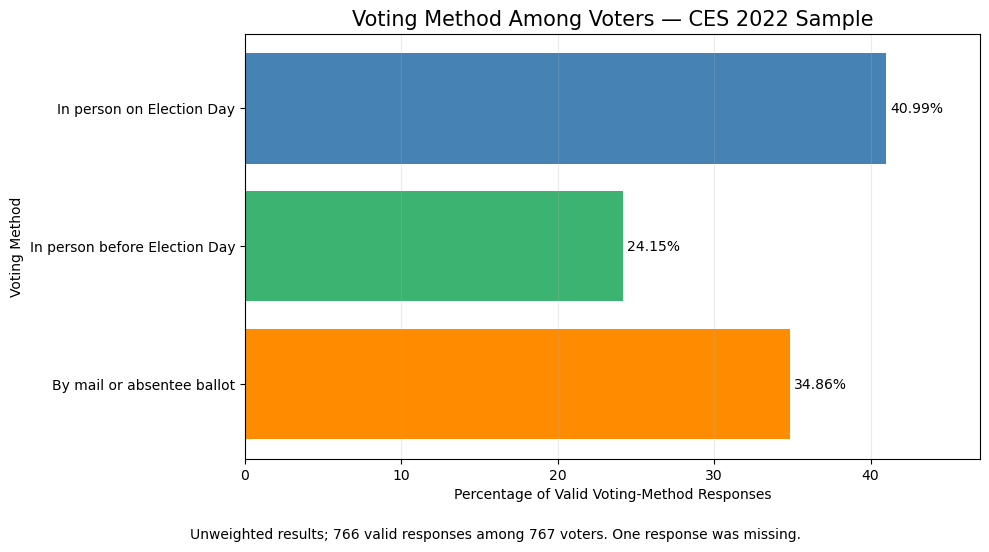

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    method_table.index,
    method_table['Percentage'],
    color=['steelblue', 'mediumseagreen', 'darkorange']
)

# Put Election Day voting at the top
ax.invert_yaxis()

# Add percentage labels
ax.bar_label(
    bars,
    fmt='%.2f%%',
    padding=3
)

ax.set_title(
    'Voting Method Among Voters — CES 2022 Sample',
    fontsize=15
)

ax.set_xlabel('Percentage of Valid Voting-Method Responses')
ax.set_ylabel('Voting Method')
ax.set_xlim(0, method_table['Percentage'].max() + 6)
ax.grid(axis='x', alpha=0.25)

fig.text(
    0.5,
    0.01,
    'Unweighted results; 766 valid responses among 767 voters. One response was missing.',
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Finding

Among the 766 voters who provided a valid voting-method response, 40.99% reported voting in person on Election Day. Another 34.86% voted by mail or absentee ballot, while 24.15% voted in person before Election Day.

Combining both in-person methods, 65.14% of respondents voted in person and 34.86% voted by mail or absentee ballot. Therefore, Election Day voting was the largest individual category, although a majority of voters used either early in-person voting or mail voting when those alternatives are considered together.

One voting-method response was missing and was excluded from the percentage calculation. These are descriptive, unweighted results from the working sample.

## Polling-Place Wait Times

### Research Question

How long did respondents who voted in person wait before voting?

In [84]:
# Keep only Election Day and early in-person voters
in_person_voters = voters[
    voters['CC22_403'].isin([1, 2])
].copy()

print("Number of in-person voters:", len(in_person_voters))

# Examine the raw wait-time response codes
in_person_voters['CC22_404'].value_counts(
    dropna=False
).sort_index()

Number of in-person voters: 499


CC22_404
1.0    246
2.0    169
3.0     65
4.0     15
5.0      3
6.0      1
Name: count, dtype: int64

In [85]:
# Translate the CES wait-time codes
wait_time_map = {
    1: 'No wait',
    2: 'Less than 10 minutes',
    3: '10–30 minutes',
    4: '31 minutes–1 hour',
    5: 'More than 1 hour',
    6: "Don't know"
}

# Create a readable wait-time column
in_person_voters['wait_time'] = (
    in_person_voters['CC22_404'].map(wait_time_map)
)

# Set the categories in their natural time order
wait_time_order = [
    'No wait',
    'Less than 10 minutes',
    '10–30 minutes',
    '31 minutes–1 hour',
    'More than 1 hour',
    "Don't know"
]

# Calculate counts
wait_time_counts = (
    in_person_voters['wait_time']
    .value_counts()
    .reindex(wait_time_order, fill_value=0)
)

# Create the results table
wait_time_table = pd.DataFrame({
    'Count': wait_time_counts,
    'Percentage': (
        wait_time_counts / wait_time_counts.sum() * 100
    ).round(2)
})

wait_time_table.index.name = 'Wait_time'

wait_time_table

,Count,Percentage
Wait_time,,
No wait,246,49.30
Less than 10 minutes,169,33.87
10–30 minutes,65,13.03
31 minutes–1 hour,15,3.01
More than 1 hour,3,0.60
Don't know,1,0.20


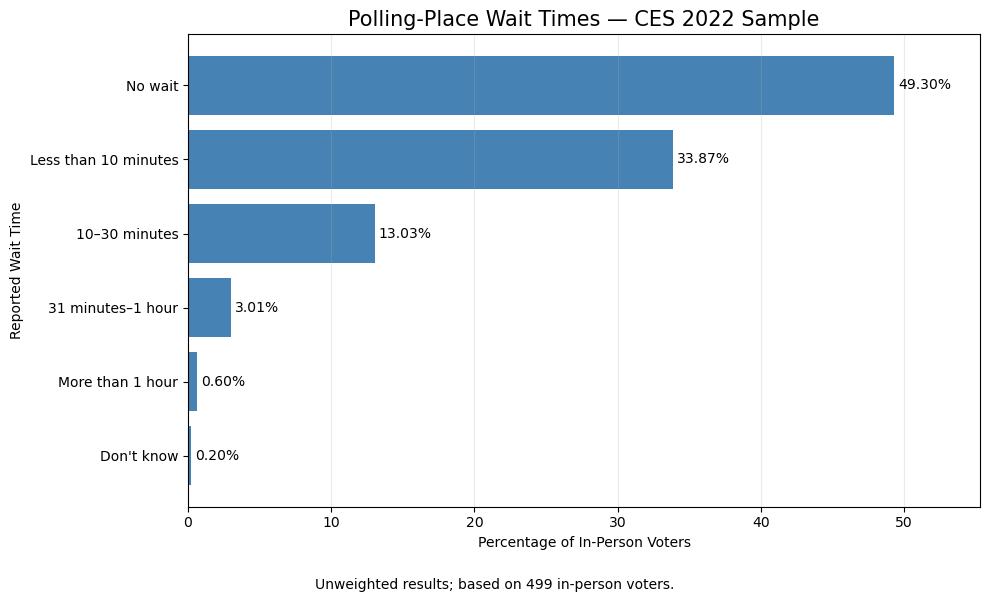

In [86]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    wait_time_table.index,
    wait_time_table['Percentage'],
    color='steelblue'
)

# Keep the categories in their natural order from shortest to longest
ax.invert_yaxis()

# Add percentage labels beside each bar
ax.bar_label(
    bars,
    fmt='%.2f%%',
    padding=3
)

ax.set_title(
    'Polling-Place Wait Times — CES 2022 Sample',
    fontsize=15
)

ax.set_xlabel('Percentage of In-Person Voters')
ax.set_ylabel('Reported Wait Time')

ax.set_xlim(
    0,
    wait_time_table['Percentage'].max() + 6
)

ax.grid(axis='x', alpha=0.25)

fig.text(
    0.5,
    0.01,
    'Unweighted results; based on 499 in-person voters.',
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Finding

Among the 499 respondents who voted in person, 49.30% reported no waiting time and 33.87% waited less than 10 minutes. Combined, 83.17% experienced either no wait or a wait shorter than 10 minutes.

Another 13.03% waited between 10 and 30 minutes. Overall, 96.20% reported waiting no more than 30 minutes. Only 3.61% waited longer than 30 minutes, including 0.60% who waited for more than one hour. One respondent selected “Don't know.”

These descriptive, unweighted results suggest that most in-person voters in the working sample experienced relatively short polling-place waits. They do not establish that wait times were equally short across all locations or among the wider US voting population.

## Voter Registration and Identification Problems

### Research Question

How common were registration or voter-identification problems among respondents who tried to vote?

In [88]:
# Keep respondents who attempted to vote or successfully voted
attempted_or_voted = voter_df[
    voter_df['CC22_401'].isin([4, 5])
].copy()

print(
    "Number who attempted to vote or successfully voted:",
    len(attempted_or_voted)
)

# Examine the raw registration/ID-problem codes
attempted_or_voted['CC22_406a'].value_counts(
    dropna=False
).sort_index()

Number who attempted to vote or successfully voted: 779


CC22_406a
1.0    751
2.0     28
Name: count, dtype: int64

In [89]:
# Translate the response codes
problem_map = {
    1: 'No problem',
    2: 'Registration or ID problem'
}

attempted_or_voted['registration_id_problem'] = (
    attempted_or_voted['CC22_406a'].map(problem_map)
)

# Set the display order
problem_order = [
    'No problem',
    'Registration or ID problem'
]

# Calculate counts
problem_counts = (
    attempted_or_voted['registration_id_problem']
    .value_counts()
    .reindex(problem_order, fill_value=0)
)

# Create the results table
problem_table = pd.DataFrame({
    'Count': problem_counts,
    'Percentage': (
        problem_counts / problem_counts.sum() * 100
    ).round(2)
})

problem_table.index.name = 'Response'

problem_table

,Count,Percentage
Response,,
No problem,751,96.41
Registration or ID problem,28,3.59


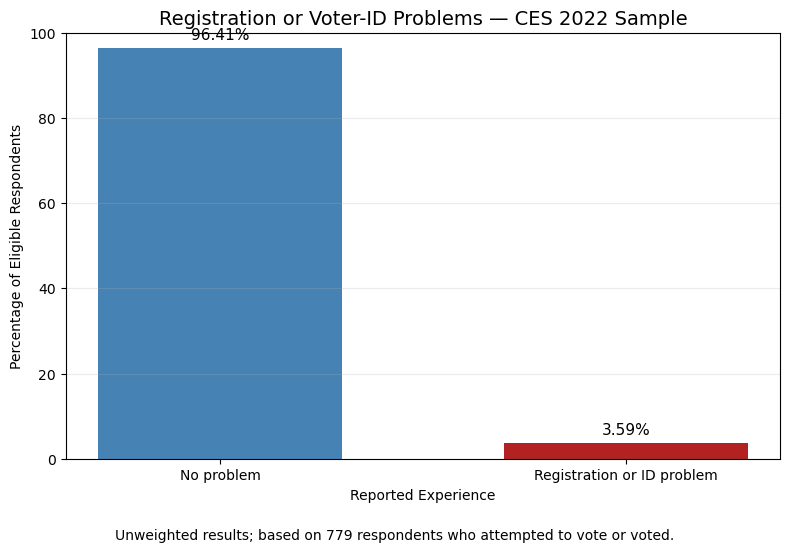

In [90]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    problem_table.index,
    problem_table['Percentage'],
    color=['steelblue', 'firebrick'],
    width=0.6
)

# Add percentage labels
for bar, value in zip(bars, problem_table['Percentage']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 2, 99),
        f'{value:.2f}%',
        ha='center',
        fontsize=11
    )

ax.set_title(
    'Registration or Voter-ID Problems — CES 2022 Sample',
    fontsize=14
)

ax.set_xlabel('Reported Experience')
ax.set_ylabel('Percentage of Eligible Respondents')

# Use the complete percentage scale
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)

fig.text(
    0.5,
    0.01,
    'Unweighted results; based on 779 respondents who attempted to vote or voted.',
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Finding

Among the 779 respondents who successfully voted or attempted to vote, 96.41% reported experiencing no registration or voter-identification problem. A smaller group of 28 respondents, representing 3.59%, reported experiencing such a problem.

Registration or identification problems were therefore uncommon in the working sample, but they were not absent. Because this question records only whether a problem occurred, the analysis does not show the exact type of problem, its severity, or whether it ultimately prevented the respondent from voting.

These results are descriptive and unweighted. They should not be interpreted as the registration or voter-ID problem rate for the entire US voting population.

# Project Summary and Conclusion

## Research Questions

Using a 1,000-respondent working sample from the 2022 Cooperative Election Study, this project examined the following questions:

1. What percentage of respondents reported voting in the 2022 midterm election?
2. How did self-reported turnout vary by gender, age, education, and party identification?
3. What was the overall distribution of identified Democratic, Republican, Independent, and Libertarian House vote choices?
4. How did House vote choice vary by gender, age, education, and party identification?
5. How did applying the CES survey weight change the estimated Democratic and Republican House vote shares?
6. What reasons did non-voters report for not voting?
7. How did voters cast their ballots—in person on Election Day, early in person, or by mail?
8. How long did in-person voters report waiting at their polling place?
9. How common were voter-registration or identification problems among respondents who attempted to vote?

## Key Findings

### 1. Self-Reported Voter Turnout

Among the 884 respondents with valid turnout information, 86.76% reported voting and 13.24% reported not voting.

Turnout increased considerably with age. It rose from approximately 67.05% among respondents aged 18–29 to 94.33% among those aged 65 and above. Turnout also generally increased with education, reaching approximately 94% among four-year degree holders and postgraduates.

Men reported a turnout rate of 89.81%, compared with 83.99% among women. Self-identified Democrats and Republicans reported similar turnout rates of approximately 90–91%, while turnout among Independents was lower at approximately 84%.

These patterns describe associations within the working sample and do not prove that age, gender, education, or party identification caused the turnout differences.

### 2. House Vote Choice

Among the 716 respondents with an identified House party choice, the unweighted results were 54.19% Democratic and 44.13% Republican. Independent and Libertarian choices each accounted for 0.84%.

House vote choice differed across demographic groups. Women showed a stronger Democratic preference than men, while the Republican share was higher among men. Democratic support declined across the age groups, from 72.73% among respondents aged 18–29 to 47.91% among respondents aged 65 and above.

Education was also associated with House vote choice. Democratic candidates received 59.31% among four-year degree holders and 66.14% among postgraduates. Respondents with a high-school education showed a Republican advantage, while those with some college or a two-year degree were more closely divided.

Party identification showed the strongest relationship with House vote choice. Approximately 96% of self-identified Democrats and Republicans selected their own party's candidate, while Independents were almost evenly divided between Democratic and Republican candidates.

### 3. Effect of Survey Weighting

The unweighted sample produced a 10.06-percentage-point Democratic advantage. After applying `commonpostweight`, the estimated result became nearly even: 49.94% Democratic and 49.42% Republican.

Weighting reduced the Democratic estimate by 4.25 percentage points and increased the Republican estimate by 5.28 points. This demonstrates that the composition of the raw sample affected the unweighted result and that survey weighting materially changed the overall estimate.

### 4. Reasons for Not Voting

Among the 117 non-voters, the most frequently reported reason was disliking the candidates, selected by 15.38%. This was followed by not knowing enough about the choices at 12.82%.

Being too busy and other unspecified reasons each accounted for 11.11%, while 10.26% reported that they were not interested. No single reason accounted for even one-fifth of non-voters, indicating that non-voting was associated with a mixture of dissatisfaction, limited information, personal circumstances, and practical barriers.

### 5. Voting Method

Among the 766 voters with a valid voting-method response, 40.99% voted in person on Election Day, 34.86% voted by mail or absentee ballot, and 24.15% voted in person before Election Day.

Combining Election Day and early voting, 65.14% voted in person. One of the 767 voters had a missing voting-method response and was excluded from these percentages.

### 6. Polling-Place Wait Times

Among the 499 in-person voters, 49.30% reported no waiting time and 33.87% waited less than 10 minutes. Combined, 83.17% experienced either no wait or a wait shorter than 10 minutes.

Overall, 96.20% reported waiting no more than 30 minutes. Only 3.61% waited longer than 30 minutes, including 0.60% who waited for more than one hour. One respondent selected “Don't know.”

### 7. Registration and Identification Problems

Among the 779 respondents who attempted to vote or successfully voted, 96.41% reported no registration or voter-identification problem. A smaller group of 28 respondents, representing 3.59%, reported experiencing such a problem.

These problems were uncommon in the working sample but were not absent. The available variable records whether a problem occurred, but it does not by itself establish the type or severity of the problem or whether it prevented the respondent from voting.

## Limitations

This analysis should be interpreted with the following limitations:

1. **The project used only the first 1,000 rows of the dataset.** The data were loaded with `nrows=1000`, meaning this was not a random sample from the complete CES dataset. The results may therefore depend on how the original file was ordered and should not be treated as nationally representative estimates.

2. **Most subgroup results were unweighted.** The comparisons involving gender, age, education, party identification, non-voting reasons, voting method, wait times, and registration or ID problems describe the working sample. Survey weighting was applied only to the overall House vote-choice comparison.

3. **Weighting does not completely solve the subset limitation.** Applying `commonpostweight` improved the population adjustment, but it was still applied to only 716 identifiable House choices from the 1,000-row subset. These figures should not be treated as official national CES estimates.

4. **Turnout and voting experiences were self-reported.** Respondents may misremember their behaviour or provide socially desirable answers. The project did not compare the answers with validated voting records.

5. **Different questions had different eligible respondents.** For example, reasons for not voting applied only to non-voters, while polling-place wait times applied only to in-person voters. Missing responses and survey skip patterns therefore produced different denominators across sections.

6. **Some categories had very small sample sizes.** Results for groups such as non-binary respondents, respondents selecting another gender, people without a high-school qualification, minor-party voters, and respondents unsure of their party identification were not sufficiently stable for strong conclusions.

7. **The analysis was descriptive.** It compared counts and percentages but did not perform significance tests, calculate confidence intervals, or control for several characteristics simultaneously. The observed patterns show associations and do not demonstrate causation.

## Conclusion

This project used a 1,000-row working subset of the 2022 Cooperative Election Study to explore self-reported voter turnout, House vote choice, reasons for non-voting, and respondents’ voting experiences.

Self-reported turnout was high among respondents with valid turnout information, but participation differed across groups. The clearest descriptive patterns appeared across age and education: older and more highly educated respondents generally reported higher turnout. Men reported moderately higher turnout than women, while Democrats and Republicans reported similar participation rates and Independents reported somewhat lower turnout.

House vote choice was strongly associated with respondents’ political and demographic characteristics. Party identification showed the clearest relationship, with approximately 96% of Democrats and Republicans selecting their own party’s House candidate. Democratic support was also higher among women, younger respondents, four-year degree holders, and postgraduates within the working sample.

Survey weighting substantially changed the overall House vote estimate. The unweighted results showed a Democratic advantage of 10.06 percentage points, while the weighted estimates were nearly even. This illustrates why raw survey percentages can be misleading when the composition of a sample differs from the population it is intended to represent.

The voting-experience results showed that non-voting did not have one dominant explanation. Respondents reported a mixture of candidate dissatisfaction, insufficient information, limited interest, personal circumstances, and practical barriers. Among voters, Election Day in-person voting was the largest individual method, although early and mail voting were also widely used. Most in-person voters reported short wait times, and registration or identification problems were reported by a small but non-zero group.

Overall, the project found meaningful descriptive associations between demographic characteristics, political identification, electoral participation, and House vote choice. However, because the analysis used only the first 1,000 dataset records and most subgroup results were unweighted, the findings should be treated as exploratory rather than nationally representative or causal.

A future extension could analyse the complete CES dataset, apply appropriate survey weights throughout, calculate confidence intervals, and use statistical models to examine whether the observed relationships remain after accounting for several respondent characteristics simultaneously.